# SpatialNoise regen test
2026-01-14

VR with help from DLR

Module where I defined old spatial noise regen and conveniency plotting functions

In [6]:
import symphony_data as sd
import spatialnoise_test as snt

<module 'spatialnoise_test' from '/Users/riekelabbackup/Desktop/Vyom/RetinAnalysis/tests/regen_tests/SpatialNoise/spatialnoise_test.py'>

## Test for comparing old and fixed regen methods

In [3]:
def test_spatialnoise_regen(exp_name, datafile_name, e_idx):
    # Get metadata for particular epoch of SpatialNoise stimulus
    param_names = ['stimulusClass', 'chromaticClass', 'noiseClass', 'frameDwell', 'stepDuration', 'gridSize', 'uniqueTime', 'repeatTime',
                'numXChecks', 'numYChecks', 'numFrames', 'numXStixels', 'numYStixels', 'stixelSize', 'stepsPerStixel', 'seed', 'stimTime','pixelDensity']

    D = sd.Dataset(exp_name)
    protocol = D.M.search_data_file('SpatialNoise', file_name=datafile_name)
    params, unique_params = D.M.get_stimulus_parameters(protocol, param_names=param_names)

    ## Regenerate frames using old method
    # Only regen first 100 frames for comparison
    num_frames = 100
    S = sd.Stimulus()
    old_regen_frames = snt.getFastNoiseFrames_old(
        S,
        int(params['numXStixels'][e_idx]),
        int(params['numYStixels'][e_idx]),
        int(params['numXChecks'][e_idx]),
        int(params['numYChecks'][e_idx]),
        params['chromaticClass'][e_idx],
        num_frames,
        int(params['stepsPerStixel'][e_idx]),
        int(params['seed'][e_idx]),
        int(params['frameDwell'][e_idx]),
        gaussianFilter=False
    )

    ## Regenerate using updated method
    fixed_regen_frames = S.getFastNoiseFrames(
        int(params['numXStixels'][e_idx]),
        int(params['numYStixels'][e_idx]),
        int(params['numXChecks'][e_idx]),
        int(params['numYChecks'][e_idx]),
        params['chromaticClass'][e_idx],
        num_frames,
        int(params['stepsPerStixel'][e_idx]),
        int(params['seed'][e_idx]),
        int(params['frameDwell'][e_idx]),
        gaussianFilter=False
    )

    # Load Ground Truth frames from .mat file for comparison
    # .mat files were regenerated with Stage in pixel space thanks to @DRezeanu method
    str_mat = f'epoch{e_idx}_{exp_name}_100frames.mat'
    ds_shape = fixed_regen_frames.shape[1:3]
    true_frames = snt.load_true_frames(str_mat, ds_shape)

    # Plot comparison for first frame
    i_frame = 0
    snt.plot_frame_comparison(true_frames, old_regen_frames, 'Old Python regen', i_frame)
    snt.plot_frame_comparison(true_frames, fixed_regen_frames, 'Fixed Python regen', i_frame)

    # Plot correlation for all frames
    snt.plot_frame_correlations(true_frames, old_regen_frames, fixed_regen_frames)

## Test for 90um stixel size, 30um grid size conditions

Full grid shape: (200, 132, 207)
Frame values shape: (200, 127, 203)
Precise Crop X: 2.00, Crop Y: 2.50
Rounded Crop X: 2, Crop Y: 2
Found frames key: frames_out
Loaded (84, 1140, 1824, 3) shape true stimulus frames from epoch9_20250514C_100frames.mat
Downsampled true stimulus frames to (84, 127, 203, 3)


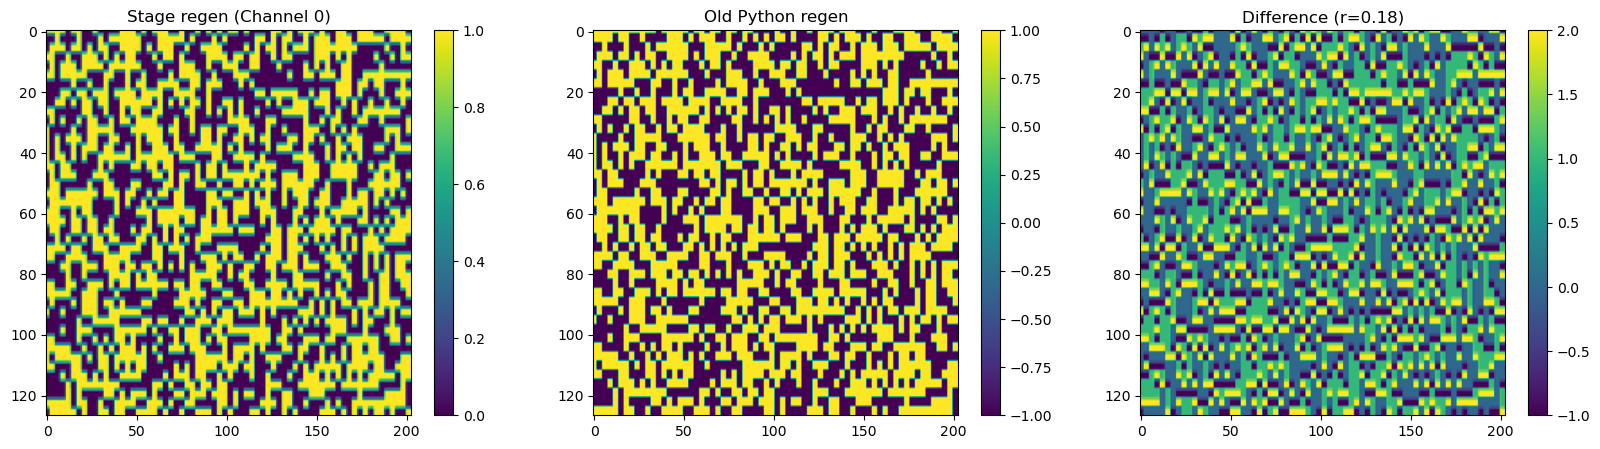

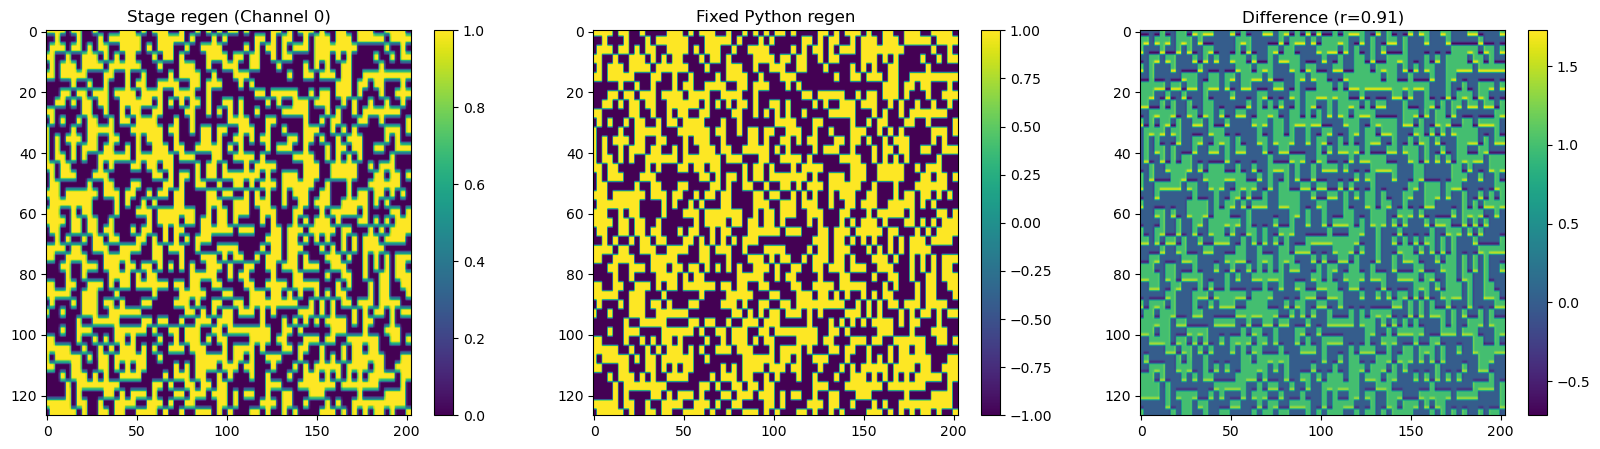

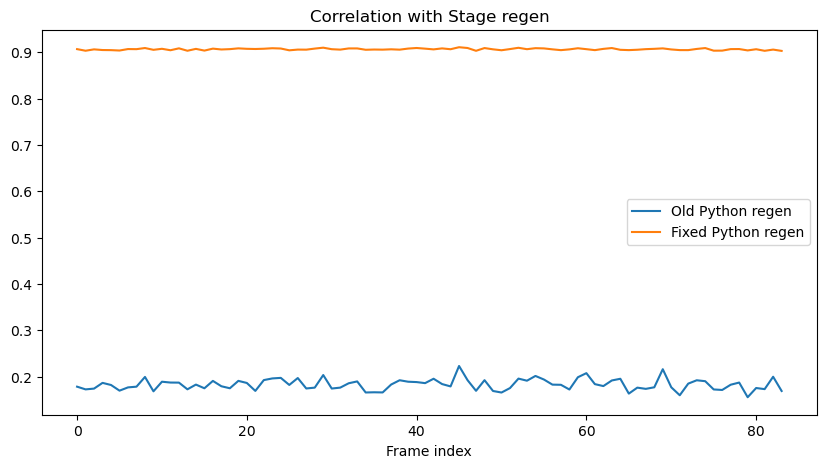

In [7]:
exp_name = '20250514C'
datafile_name = 'data001'
e_idx = 9
test_spatialnoise_regen(exp_name, datafile_name, e_idx)

Full grid shape: (200, 132, 207)
Frame values shape: (200, 127, 203)
Precise Crop X: 2.00, Crop Y: 2.50
Rounded Crop X: 2, Crop Y: 2
Found frames key: frames
Loaded (85, 1140, 1824, 3) shape true stimulus frames from epoch0_20251216C_100frames.mat
Downsampled true stimulus frames to (85, 127, 203, 3)


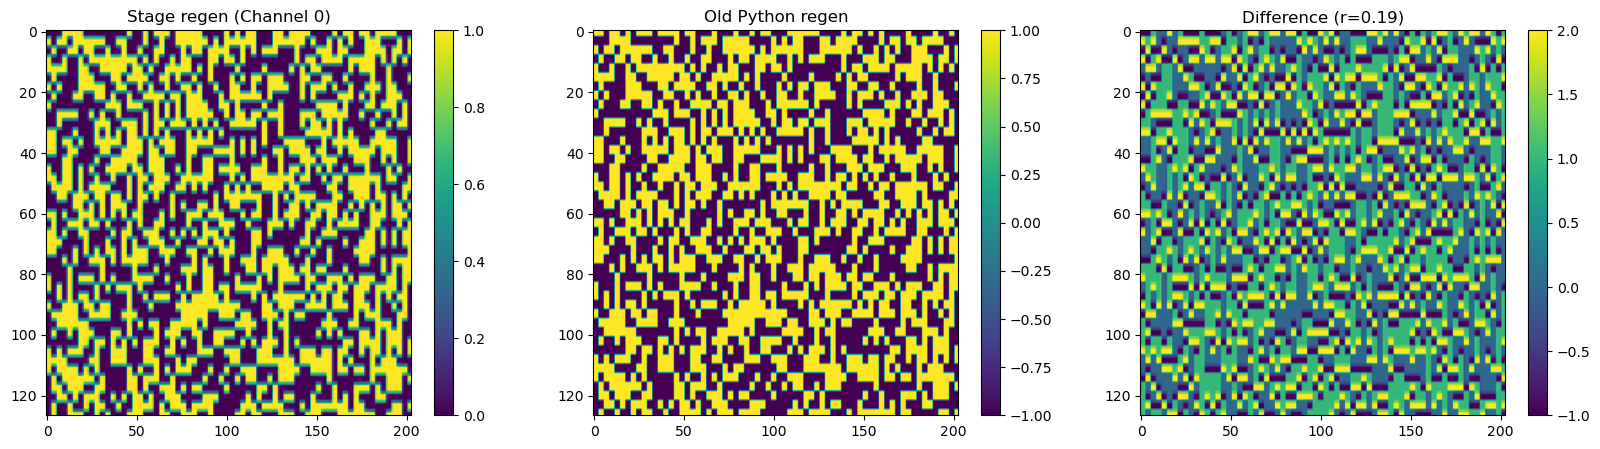

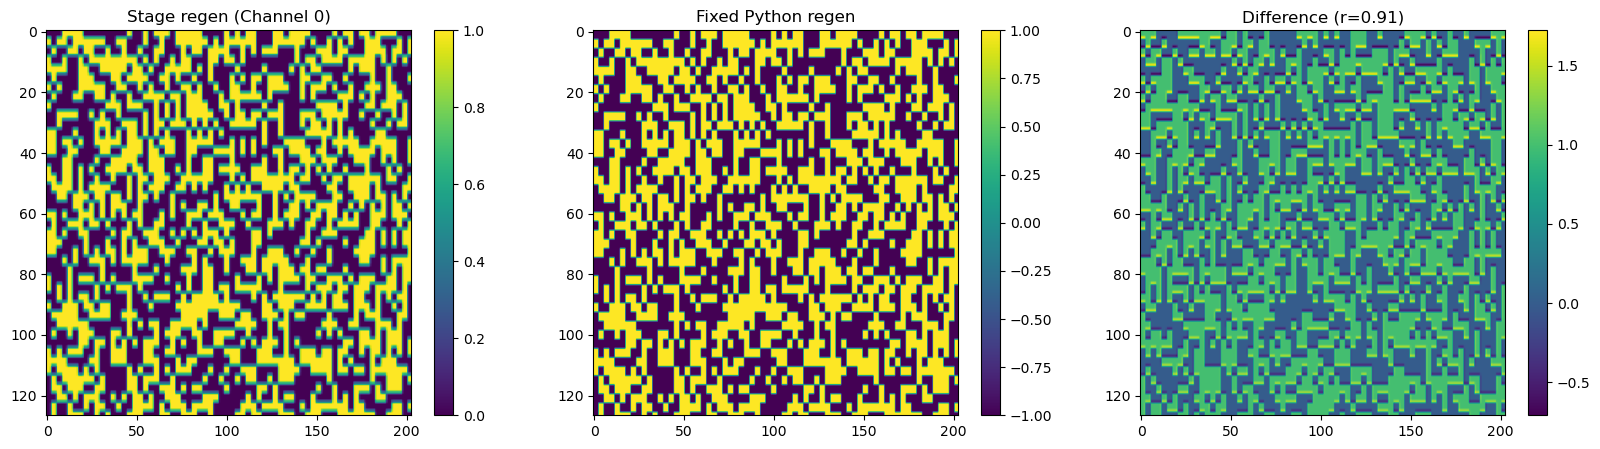

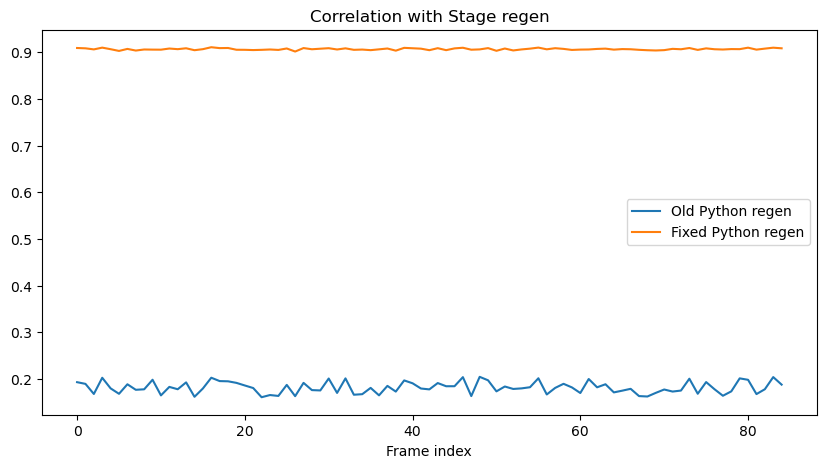

In [8]:
exp_name = '20251216C'
datafile_name = 'data001'
e_idx = 0
test_spatialnoise_regen(exp_name, datafile_name, e_idx)

## Test for 150um stixel size, 30um grid size condition

Full grid shape: (200, 135, 210)
Frame values shape: (200, 127, 203)
Precise Crop X: 3.50, Crop Y: 4.00
Rounded Crop X: 4, Crop Y: 4
Found frames key: frames
Loaded (85, 1140, 1824, 3) shape true stimulus frames from epoch2_20251216C_100frames.mat
Downsampled true stimulus frames to (85, 127, 203, 3)


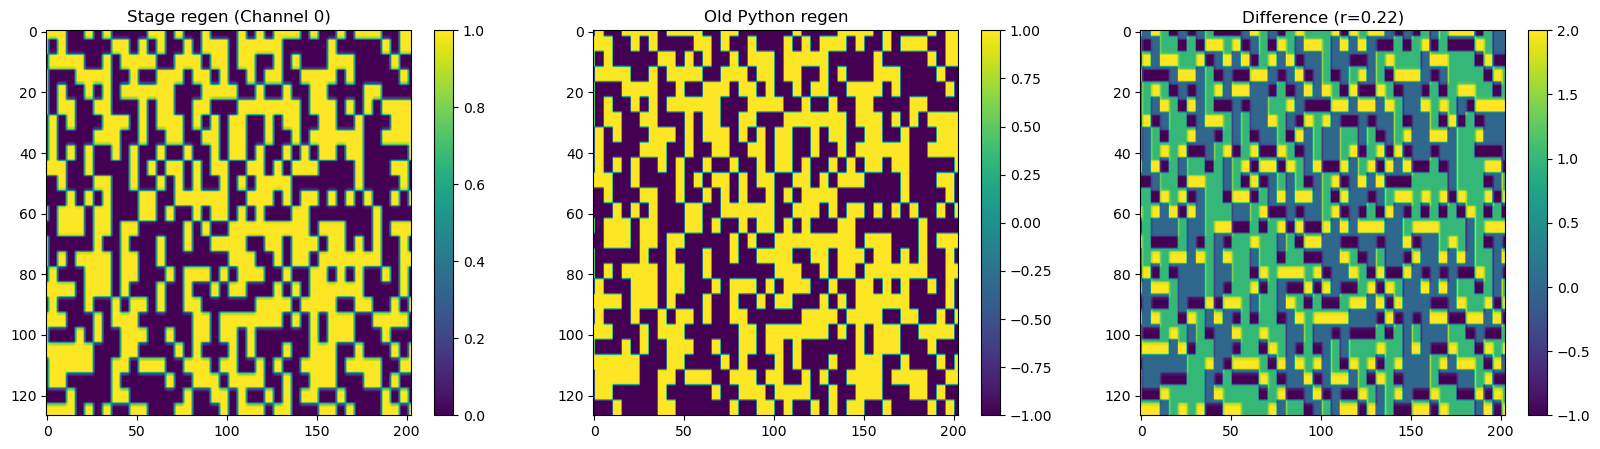

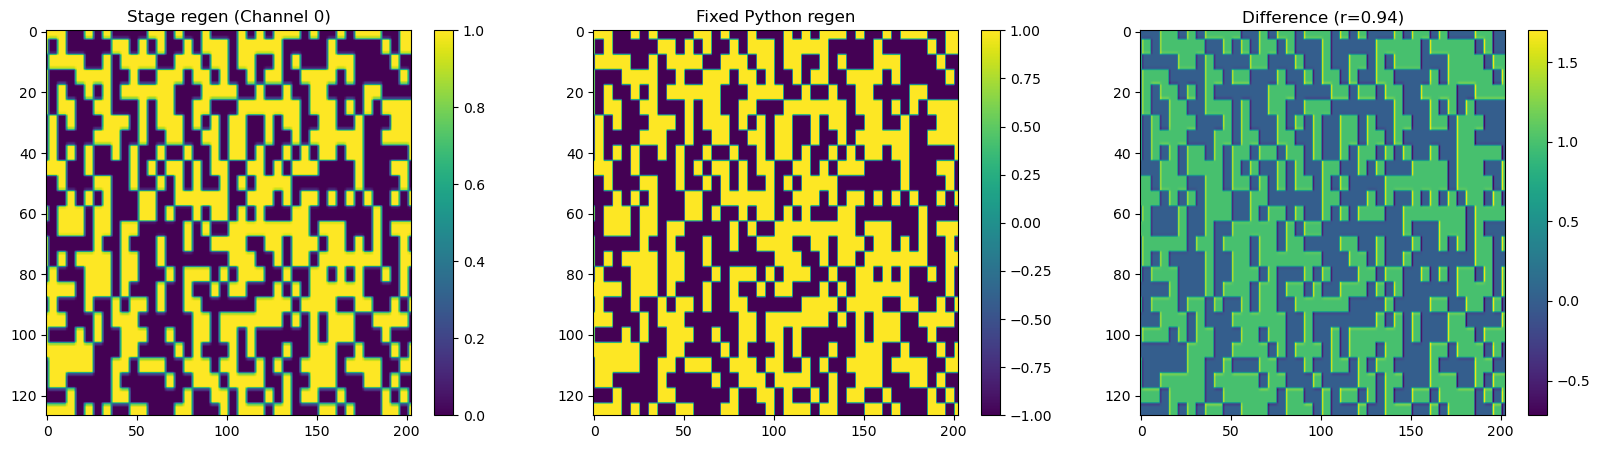

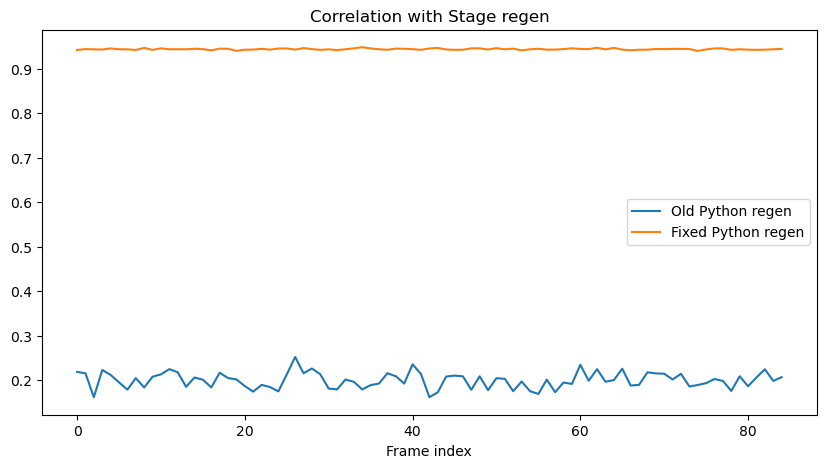

In [9]:
exp_name = '20251216C'
datafile_name = 'data001'
e_idx = 2
test_spatialnoise_regen(exp_name, datafile_name, e_idx)

Even with the fix regen is imperfect, I believe because we regen in a downsampled (127, 203) space which does not evenly scale up to full (1140, 1824) pixel space.